# Predict Accessibility for EFS.fa

This notebook loads the sequences in `EFS.fa`, pads each sequence to a supported AlphaGenome input length, predicts DNase accessibility across all available Homo sapiens tracks, summarizes the strongest accessibility signals, and visualizes a sampled subset of tracks.

In [1]:
from pathlib import Path
import os
import subprocess

from alphagenome import colab_utils
from alphagenome.models import dna_client
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 120

/opt/anaconda3/envs/alphagenome-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if 'ALPHA_GENOME_API_KEY' not in os.environ:
    os.environ['ALPHA_GENOME_API_KEY'] = subprocess.check_output(
        ['op', 'read', 'op://Private/AlphaGenome API Credential/credential'],
        text=True,
    ).strip()

dna_model = dna_client.create(colab_utils.get_api_key())

In [3]:
efs_path = Path('./EFS.fa')
supported_lengths = sorted(dna_client.SUPPORTED_SEQUENCE_LENGTHS.values())


def read_fasta(path: Path) -> list[tuple[str, str]]:
    records = []
    header = None
    chunks = []
    with path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if header is not None:
                    records.append((header, ''.join(chunks).upper()))
                header = line[1:]
                chunks = []
            else:
                chunks.append(line)

    if header is not None:
        records.append((header, ''.join(chunks).upper()))

    if not records:
        raise ValueError(f'No FASTA records found in {path}.')

    return records


def choose_supported_length(length: int) -> int:
    for supported_length in supported_lengths:
        if length <= supported_length:
            return supported_length
    raise ValueError(
        'Sequence is longer than the largest AlphaGenome-supported length: '
        f'{length} > {supported_lengths[-1]}'
    )


def normalize_sequence(sequence: str) -> tuple[str, int, int, int]:
    invalid_bases = sorted(set(sequence) - set('ACGTN'))
    if invalid_bases:
        raise ValueError(
            'Sequences must contain only A, C, G, T, or N. '
            f'Found invalid bases: {invalid_bases}'
        )

    target_length = choose_supported_length(len(sequence))
    left_padding = (target_length - len(sequence)) // 2
    right_padding = target_length - len(sequence) - left_padding
    normalized = 'N' * left_padding + sequence + 'N' * right_padding
    return normalized, target_length, left_padding, left_padding + len(sequence)


def make_track_label(row: pd.Series) -> str:
    label_parts = [f"track {row['track_index']}"]
    for column in ['cell_type', 'name', 'ontology_curie']:
        value = row.get(column)
        if pd.notna(value) and value not in label_parts:
            label_parts.append(str(value))
    return ' | '.join(label_parts)

In [4]:
records = read_fasta(efs_path)

prepared_records = []
for sequence_name, sequence in records:
    normalized_sequence, model_length, insert_start, insert_end = normalize_sequence(sequence)
    prepared_records.append(
        {
            'sequence_name': sequence_name,
            'original_length': len(sequence),
            'model_length': model_length,
            'insert_start': insert_start,
            'insert_end': insert_end,
            'normalized_sequence': normalized_sequence,
        }
    )

sequence_table = pd.DataFrame(prepared_records)
sequence_table[
    ['sequence_name', 'original_length', 'model_length', 'insert_start', 'insert_end']
].copy()

,sequence_name,original_length,model_length,insert_start,insert_end
0,MM-EFS-1,4398,16384,5993,10391
1,MM-EFS-2,4398,16384,5993,10391
2,MM-EFS-3,4398,16384,5993,10391
3,MM-EFS-4,4398,16384,5993,10391
4,MM-EFS-5,4398,16384,5993,10391
5,MM-EFS-6,4398,16384,5993,10391
6,MM-EFS-7,4398,16384,5993,10391
7,MM-EFS-8,4398,16384,5993,10391
8,MM-EFS-9,4398,16384,5993,10391
9,MM-EFS-10,4398,16384,5993,10391


## Predict DNase Accessibility

Setting `ontology_terms=None` requests all available Homo sapiens DNase ontologies exposed by AlphaGenome.

In [5]:
outputs = dna_model.predict_sequences(
    sequences=sequence_table['normalized_sequence'].tolist(),
    organism=dna_client.Organism.HOMO_SAPIENS,
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=None,
    progress_bar=True,
    max_workers=2,
    intervals=None,
)

dnase_outputs = [output.dnase for output in outputs]

{
    'num_sequences': len(dnase_outputs),
    'first_output_shape': dnase_outputs[0].values.shape,
    'first_output_resolution_bp': dnase_outputs[0].resolution,
}

I0403 17:11:50.581058 5418998 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers
I0403 17:11:50.584410 5419644 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(92, generation: 1)
100%|██████████| 10/10 [00:02<00:00,  4.67it/s]


{'num_sequences': 10,
 'first_output_shape': (16384, 305),
 'first_output_resolution_bp': 1}

In [6]:
prediction_summary = sequence_table[
    ['sequence_name', 'original_length', 'model_length', 'insert_start', 'insert_end']
].copy()
prediction_summary['num_dnase_tracks'] = [dnase.num_tracks for dnase in dnase_outputs]
prediction_summary['num_bins'] = [dnase.values.shape[0] for dnase in dnase_outputs]
prediction_summary['track_resolution_bp'] = [dnase.resolution for dnase in dnase_outputs]

track_metadata = dnase_outputs[0].metadata.reset_index(drop=True).copy()
track_metadata['track_index'] = track_metadata.index

prediction_summary

,sequence_name,original_length,model_length,insert_start,insert_end,num_dnase_tracks,num_bins,track_resolution_bp
0,MM-EFS-1,4398,16384,5993,10391,305,16384,1
1,MM-EFS-2,4398,16384,5993,10391,305,16384,1
2,MM-EFS-3,4398,16384,5993,10391,305,16384,1
3,MM-EFS-4,4398,16384,5993,10391,305,16384,1
4,MM-EFS-5,4398,16384,5993,10391,305,16384,1
5,MM-EFS-6,4398,16384,5993,10391,305,16384,1
6,MM-EFS-7,4398,16384,5993,10391,305,16384,1
7,MM-EFS-8,4398,16384,5993,10391,305,16384,1
8,MM-EFS-9,4398,16384,5993,10391,305,16384,1
9,MM-EFS-10,4398,16384,5993,10391,305,16384,1


In [7]:
per_sequence_track_scores = []
for sequence_name, dnase in zip(sequence_table['sequence_name'], dnase_outputs, strict=True):
    score_table = track_metadata.copy()
    score_table['sequence_name'] = sequence_name
    score_table['mean_accessibility'] = dnase.values.mean(axis=0)
    score_table['max_accessibility'] = dnase.values.max(axis=0)
    per_sequence_track_scores.append(score_table)

track_scores = pd.concat(per_sequence_track_scores, ignore_index=True)

metadata_columns = [
    column
    for column in [
        'track_index',
        'name',
        'cell_type',
        'ontology_curie',
        'biosample_type',
        'developmental_stage',
        'assay',
    ]
    if column in track_metadata.columns
]

global_track_ranking = (
    track_scores.groupby('track_index', as_index=False)
    .agg(
        mean_accessibility=('mean_accessibility', 'mean'),
        max_accessibility=('max_accessibility', 'max'),
    )
    .merge(track_metadata[metadata_columns], on='track_index', how='left')
    .sort_values(['mean_accessibility', 'max_accessibility'], ascending=False)
    .reset_index(drop=True)
 )

sequence_level_top_tracks = (
    track_scores.sort_values(
        ['sequence_name', 'mean_accessibility'],
        ascending=[True, False],
    )
    .groupby('sequence_name')
    .head(10)
    .reset_index(drop=True)
 )

prediction_summary.to_csv('efs_prediction_summary.csv', index=False)
track_scores.to_csv('efs_dnase_track_scores.csv', index=False)
global_track_ranking.to_csv('efs_dnase_global_track_ranking.csv', index=False)
sequence_level_top_tracks.to_csv('efs_dnase_top_tracks_per_sequence.csv', index=False)

global_track_ranking.head(10)

,track_index,mean_accessibility,max_accessibility,name,ontology_curie,biosample_type
0,173,0.150158,23.87500,EFO:0005720 DNase-seq,EFO:0005720,cell_line
1,93,0.129360,17.87500,CL:2000045 DNase-seq,CL:2000045,primary_cell
2,248,0.077486,9.75000,UBERON:0001875 DNase-seq,UBERON:0001875,tissue
3,225,0.066154,7.00000,UBERON:0000988 DNase-seq,UBERON:0000988,tissue
4,247,0.048530,7.46875,UBERON:0001874 DNase-seq,UBERON:0001874,tissue
5,143,0.046475,18.62500,EFO:0002793 DNase-seq,EFO:0002793,cell_line
6,275,0.045990,14.62500,UBERON:0002740 DNase-seq,UBERON:0002740,tissue
7,290,0.044799,6.21875,UBERON:0008953 DNase-seq,UBERON:0008953,tissue
8,274,0.043731,16.12500,UBERON:0002626 DNase-seq,UBERON:0002626,tissue
9,46,0.043511,34.00000,CL:0002061 DNase-seq,CL:0002061,primary_cell


## Visualize Sampled Tracks

The full DNase output contains many tracks, so the plot below uses the highest-mean tracks across the EFS sequences and highlights the original insert span within the padded model input.

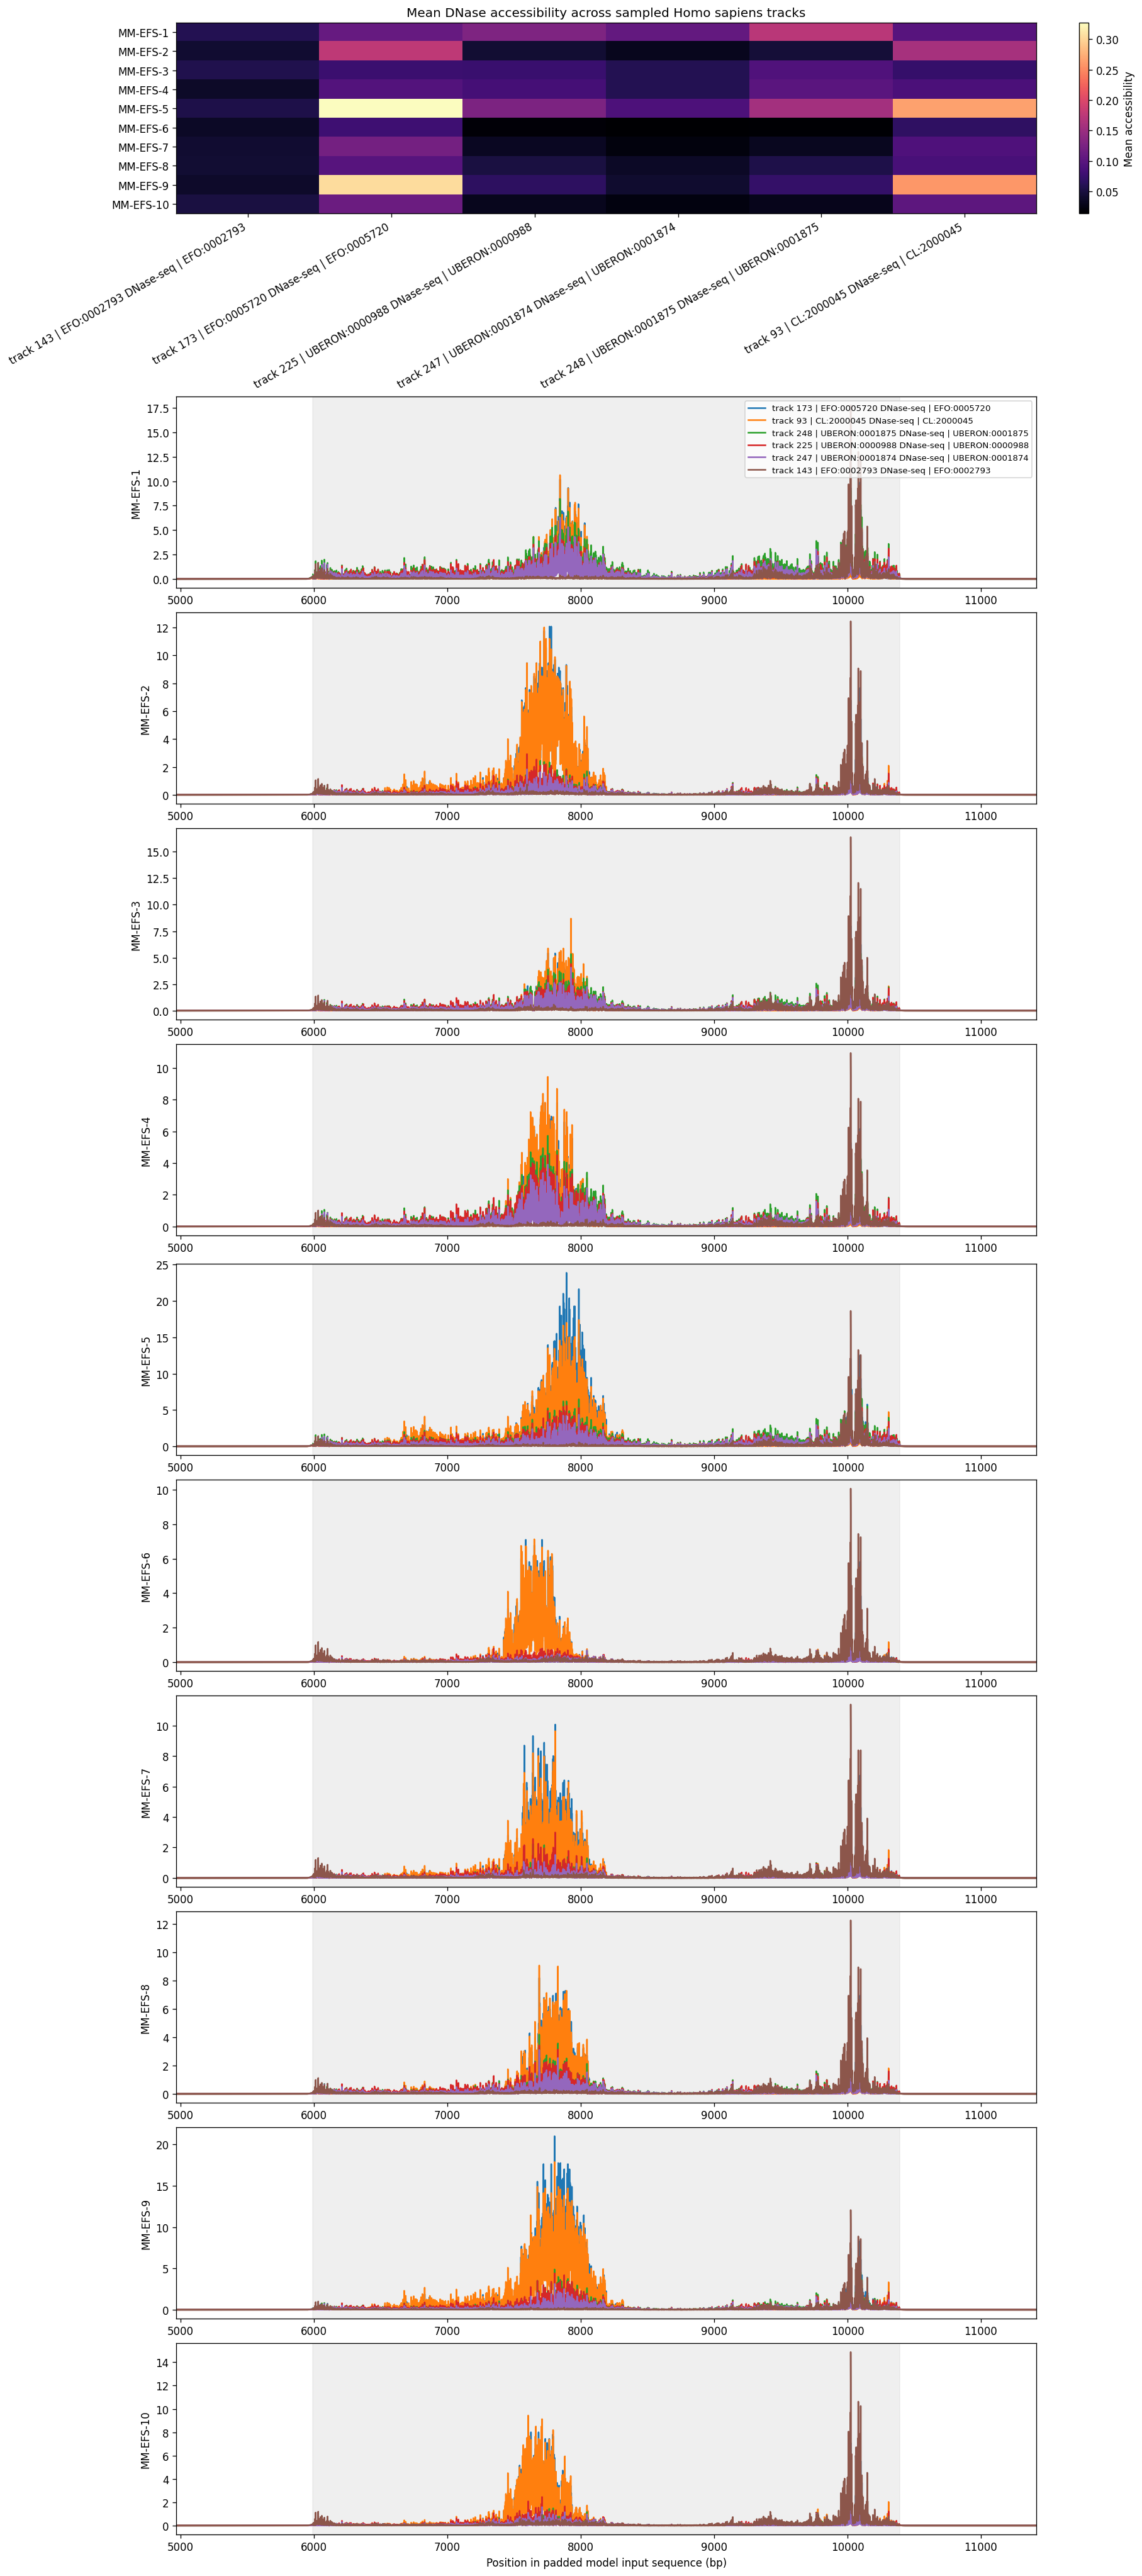

In [8]:
sampled_track_indices = global_track_ranking.head(
    min(6, len(global_track_ranking))
)['track_index'].tolist()

sampled_track_rows = track_metadata.loc[sampled_track_indices].copy()
sampled_track_rows['plot_label'] = sampled_track_rows.apply(make_track_label, axis=1)

mean_heatmap = (
    track_scores[track_scores['track_index'].isin(sampled_track_indices)]
    .merge(
        sampled_track_rows[['track_index', 'plot_label']],
        on='track_index',
        how='left',
    )
    .pivot(index='sequence_name', columns='plot_label', values='mean_accessibility')
    .loc[sequence_table['sequence_name']]
 )

fig, axes = plt.subplots(
    nrows=len(sequence_table) + 1,
    ncols=1,
    figsize=(15, 3 * len(sequence_table) + 4),
    constrained_layout=True,
 )

heatmap_ax = axes[0]
heatmap = mean_heatmap.to_numpy(dtype=float)
image = heatmap_ax.imshow(heatmap, aspect='auto', cmap='magma')
heatmap_ax.set_xticks(np.arange(mean_heatmap.shape[1]))
heatmap_ax.set_xticklabels(mean_heatmap.columns, rotation=30, ha='right')
heatmap_ax.set_yticks(np.arange(mean_heatmap.shape[0]))
heatmap_ax.set_yticklabels(mean_heatmap.index)
heatmap_ax.set_title('Mean DNase accessibility across sampled Homo sapiens tracks')
fig.colorbar(image, ax=heatmap_ax, label='Mean accessibility')

for axis_offset, (_, row) in enumerate(sequence_table.iterrows(), start=1):
    dnase = dnase_outputs[axis_offset - 1]
    ax = axes[axis_offset]
    x_positions = np.arange(dnase.values.shape[0]) * dnase.resolution

    for track_index, plot_label in zip(
        sampled_track_indices,
        sampled_track_rows['plot_label'],
        strict=True,
    ):
        ax.plot(x_positions, dnase.values[:, track_index], linewidth=1.5, label=plot_label)

    ax.axvspan(row['insert_start'], row['insert_end'], color='lightgrey', alpha=0.35)
    window_start = max(0, row['insert_start'] - 1024)
    window_end = min(row['model_length'], row['insert_end'] + 1024)
    ax.set_xlim(window_start, window_end)
    ax.set_ylabel(row['sequence_name'])
    if axis_offset == 1:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position in padded model input sequence (bp)')
plt.show()